# Set-up

In [3]:
import os
from collections import defaultdict
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [4]:
import wandb

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("wandb_api")
    wandb.login(key=api_key)
    anony = None
except:
    anony = "must"
    print('If you want to use your W&B account, go to Add-ons -> Secrets and provide your W&B access token. Use the Label name as wandb_api. \nGet your W&B access token from here: https://wandb.ai/authorize')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: iq000012 (infinitasfish). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [ ]:
!unzip ../input/anomaly

# Data prep.

In [5]:
ds_path = '../input/anomaly/dataset'

In [6]:
for root, dirs, paths in os.walk(ds_path):
  print(root, dirs, len(paths))

../input/anomaly/dataset ['proliv', 'test', 'train'] 0
../input/anomaly/dataset/proliv [] 154
../input/anomaly/dataset/test ['imgs'] 1
../input/anomaly/dataset/test/imgs [] 3794
../input/anomaly/dataset/train [] 10000


In [7]:
class anomaly_dataset(Dataset):
  def __init__(self, ds_path, split, annotations_file=None, transform=None):
    self.ds_path = ds_path
    self.split = split.lower()

    if (self.split == 'test' and annotations_file is not None):
      test_images = os.path.join(self.ds_path, 'test', 'imgs')
      test_labels = os.path.join(self.ds_path, 'test', annotations_file)

      self.images_paths = sorted(os.listdir(test_images))
      self.labels_list = []
      with open(test_labels, 'r') as f:
        lines = sorted([line for line in f], key=lambda l: l.split()[0])
        self.labels_list = [int(line.split()[1]) for line in lines]
    else:
      split_path = os.path.join(self.ds_path, self.split)
      self.images_paths = sorted(os.listdir(split_path))

    self.transform = transform

  def __len__(self):
    return len(self.images_paths)

  def __getitem__(self, index):
    if self.split == 'test':
      label = self.labels_list[index]
      image_path = os.path.join(self.ds_path, self.split, 'imgs', self.images_paths[index])
      image = cv2.imread(image_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      image_t = self.transform(image)
      image_t = transforms.functional.adjust_contrast(image_t, contrast_factor=1.5)
      return image_t, label
    else:
      image_path = os.path.join(ds_path, self.split, self.images_paths[index])
      image = cv2.imread(image_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      image_t = self.transform(image)
      image_t = transforms.functional.adjust_contrast(image_t, contrast_factor=1.5)
      return image_t


In [8]:
# first_tform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Resize((30, 50))
# ])

norm_tform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = anomaly_dataset(ds_path, 'train', transform=norm_tform)
proliv_ds = anomaly_dataset(ds_path, 'proliv', transform=norm_tform)
test_ds = anomaly_dataset(ds_path, 'test', 'test_annotation.txt', transform=norm_tform)
print(len(train_ds), len(proliv_ds), len(test_ds))


10000 154 3794


torch.Size([3, 64, 64])


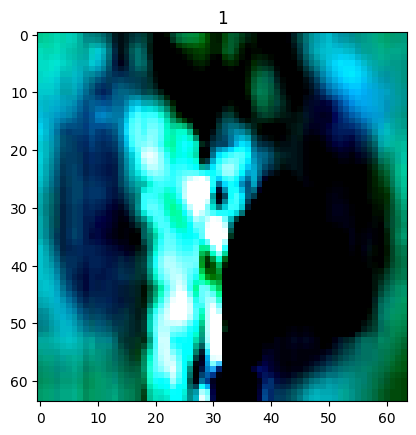

In [9]:
for i in range(len(test_ds)):
  image, label = test_ds[i]
  if i == 1000: break
  if label == 1: break

plt.title(str(label))
plt.imshow(image.squeeze().permute(1, 2, 0).cpu().numpy())
print(image.shape)

# Baselines

In [10]:

## FIRST VERSION
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(1500, 784),
            nn.ReLU(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.dec = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.ReLU(),
            nn.Linear(784, 1500),
            nn.ReLU()
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        encode = self.enc(x)
        decode = self.dec(encode)
        return decode

In [11]:

## SECOND VERSION: Convolutional AE
class AE2(nn.Module):
    def __init__(self):
        super(AE2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # (16, 30, 50)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # (16, 15, 25)
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),   # (8, 15, 25)
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16,
                               kernel_size=3,
                               stride=2,
                               padding=1,
                               output_padding=1),  # (16, 30, 50)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3,
                               kernel_size=3,
                               stride=1,
                               padding=1,
                               output_padding=0), # (3, 30, 50)
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [12]:

## DEEPER (+conv)
class AE3(nn.Module):
    def __init__(self):
        super(AE3, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),                           

            nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),                           

            nn.Conv2d(in_channels=8, out_channels=4, kernel_size=3, stride=1, padding=1), 
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=4, out_channels=8, kernel_size=3, stride=2, padding=1, output_padding=1),  
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=0), 
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3, stride=1, padding=1, output_padding=0), 
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [13]:

## more params in conv layers
class AE4(nn.Module):
    def __init__(self):
        super(AE4, self).__init__()

        self.encoder = nn.Sequential(
            #
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),  
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='nearest'),  
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            
            nn.Conv2d(in_channels=32, out_channels=3, kernel_size=3, stride=1, padding=1),  
            nn.Sigmoid() 
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Train loop

In [14]:
batch_size = 256
lr = 6e-3
w_d = 1e-5
epochs = 120

In [15]:
tfrom_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.3),
    transforms.RandomVerticalFlip(0.3),
    #transforms.RandomRotation(degrees=(-25, 25)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = anomaly_dataset(ds_path, 'train', transform=tfrom_aug)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

In [16]:
metrics = defaultdict(list)
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model = AE4()
model.to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=w_d)

In [17]:
run = wandb.init(
    project="ae4_aug_train",
    config={
        "learning_rate": lr,
        "epochs": epochs,
    },
)

In [18]:
model.train()
start = time.time()
for epoch in tqdm(range(epochs)):
  ep_start = time.time()
  running_loss = 0.0
  for i, data in enumerate(train_dl):
    pred = model(data.to(device))
    #flat = torch.flatten(data.to(device), start_dim=1)
    loss = criterion(data.to(device), pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  epoch_loss = running_loss/len(train_dl)
  wandb.log({'epoch': epoch,
             'train_loss': epoch_loss,})

  metrics['train_loss'].append(epoch_loss)
  ep_end = time.time()
  print('\n-----------------------------------------------')
  print(f'epoch: {epoch}\ttrain_loss: {epoch_loss:.5f}')
  print(f'epoch completed in {(ep_end-ep_start)/60:.2f} mins')

end = time.time()
print('\n-----------------------------------------------')
print(f'training completed in {(end-start)/60:.2f} mins')

  1%|          | 1/120 [00:39<1:18:17, 39.47s/it]


-----------------------------------------------
epoch: 0	train_loss: 0.05027
epoch completed in 0.66 mins


  2%|▏         | 2/120 [00:50<44:18, 22.53s/it]  


-----------------------------------------------
epoch: 1	train_loss: 0.01313
epoch completed in 0.18 mins


  2%|▎         | 3/120 [01:00<32:52, 16.86s/it]

...


-----------------------------------------------
epoch: 117	train_loss: 0.00131
epoch completed in 0.17 mins


 99%|█████████▉| 119/120 [20:51<00:10, 10.18s/it]


-----------------------------------------------
epoch: 118	train_loss: 0.00127
epoch completed in 0.17 mins


100%|██████████| 120/120 [21:01<00:00, 10.51s/it]


-----------------------------------------------
epoch: 119	train_loss: 0.00130
epoch completed in 0.17 mins

-----------------------------------------------
training completed in 21.03 mins


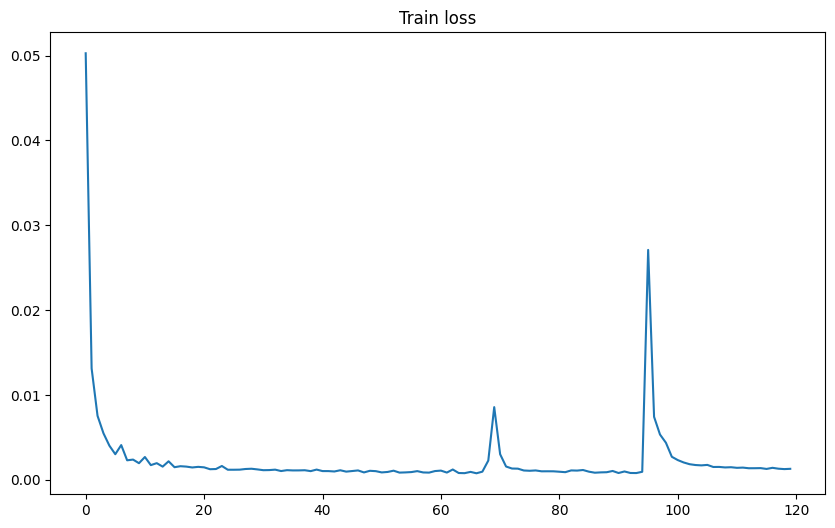

In [19]:
_, ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Train loss')
ax.plot(metrics['train_loss'])

In [20]:
checkpoint = {'model': AE4(),
              'state_dict': model.state_dict(),
              'optimizer' : optimizer.state_dict()}

torch.save(checkpoint, '125_checkpoint.pth')

# Threshold

In [21]:
proliv_dl = DataLoader(
    proliv_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

train_dl = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

loss_dist_pos = []
loss_dist_neg = []

model.eval()

# what if using 'sum' reduction to distict anomalies more easily..
criterion = nn.MSELoss(reduction='sum')

for i, data in tqdm(enumerate(train_dl)):
    pred = model(data.to(device))
    #flat = torch.flatten(data.to(device), start_dim=1)
    loss = criterion(data.to(device), pred)
    loss_dist_neg.append(loss.detach().cpu().numpy())

for i, data in tqdm(enumerate(proliv_dl)):
    pred = model(data.to(device))
    #flat = torch.flatten(data.to(device), start_dim=1)
    loss = criterion(data.to(device), pred)
    loss_dist_pos.append(loss.detach().cpu().numpy())

10000it [00:20, 477.52it/s]
154it [00:00, 204.65it/s]


<Figure size 1000x600 with 0 Axes>

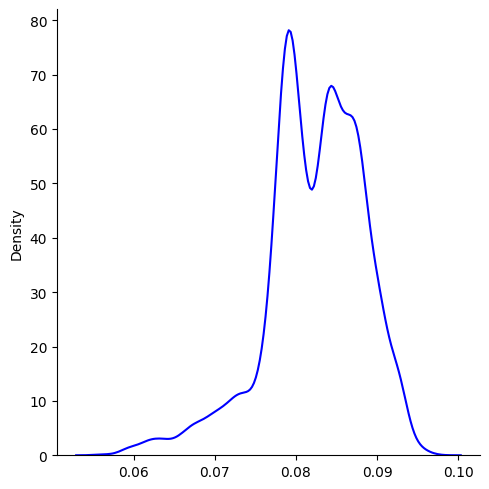

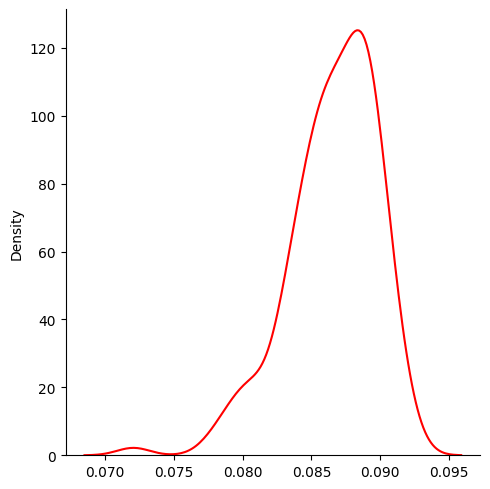

In [ ]:
# DO NOT DELETE
# linear baseline, mse, no augmentations, no normalization, grayscale, 100 epochs
# not very useful

plt.figure(figsize=(10, 6))
sns.displot(np.array(loss_dist_neg), kind='kde', color='blue')
sns.displot(np.array(loss_dist_pos), kind='kde', color='red')
plt.show()

<Figure size 1000x600 with 0 Axes>

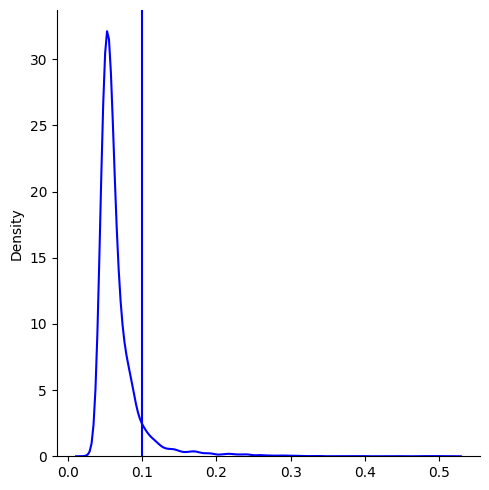

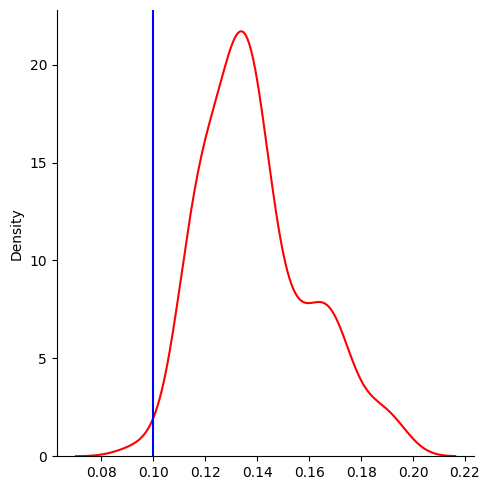

In [ ]:
# DO NOT DELETE
# convolution baseline, mse, no augmentations, normalization, rgb, 200 epochs
# pretty good

thr = 0.1

plt.figure(figsize=(10, 6))
sns.displot(np.array(loss_dist_neg), kind='kde', color='blue')
plt.axvline(x = thr, color = 'b')
sns.displot(np.array(loss_dist_pos), kind='kde', color='red')
plt.axvline(x = thr, color = 'b')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1000x600 with 0 Axes>

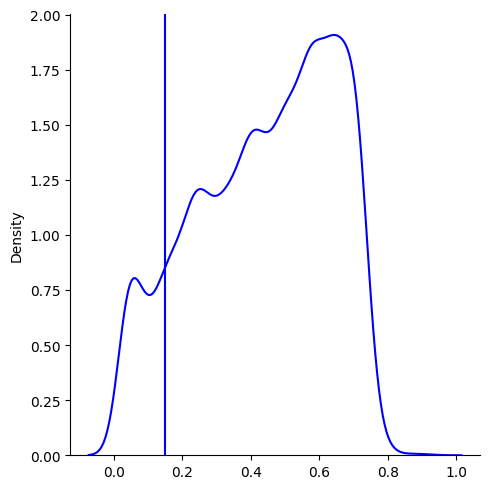

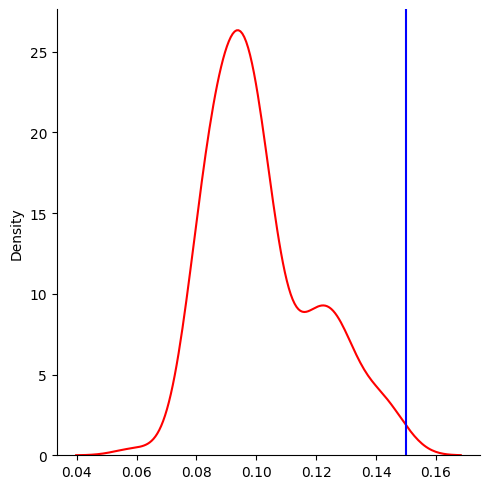

In [45]:
# DO NOT DELETE
# convolution baseline, mse, plus augmentations, normalization, rgb, 200 epochs

thr = 0.15

plt.figure(figsize=(10, 6))
sns.displot(np.array(loss_dist_neg), kind='kde', color='blue')
plt.axvline(x = thr, color = 'b')
sns.displot(np.array(loss_dist_pos), kind='kde', color='red')
plt.axvline(x = thr, color = 'b')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1000x600 with 0 Axes>

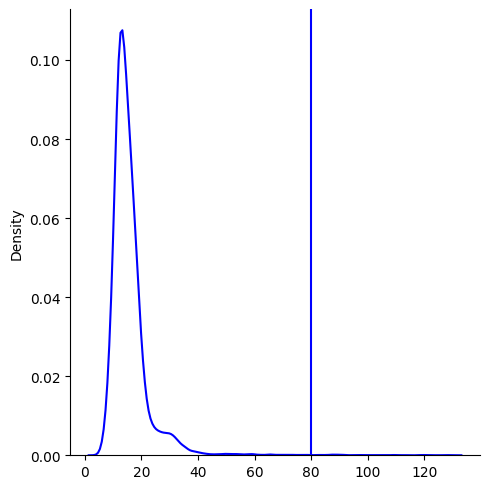

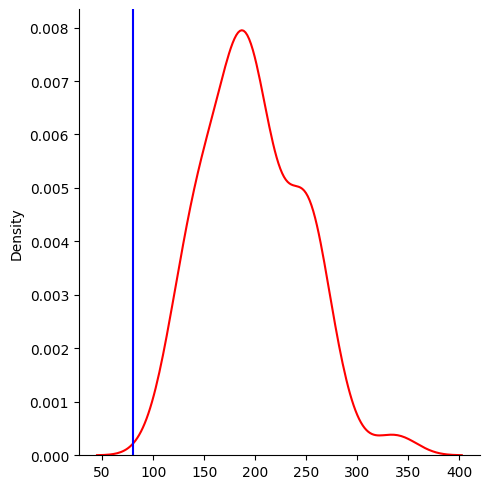

In [29]:
# DO NOT DELETE
# DEEPER convolution baseline, mse, without rotation augmentation, rgb, 200 epochs
# sum reduction

thr = 80
plt.figure(figsize=(10, 6))
sns.displot(np.array(loss_dist_neg), kind='kde', color='blue')
plt.axvline(x = thr, color = 'b')
sns.displot(np.array(loss_dist_pos), kind='kde', color='red')
plt.axvline(x = thr, color = 'b')
plt.show()

# Testing

torch.Size([128, 3, 64, 64]) torch.Size([128, 3, 64, 64])


<Figure size 1600x1200 with 0 Axes>

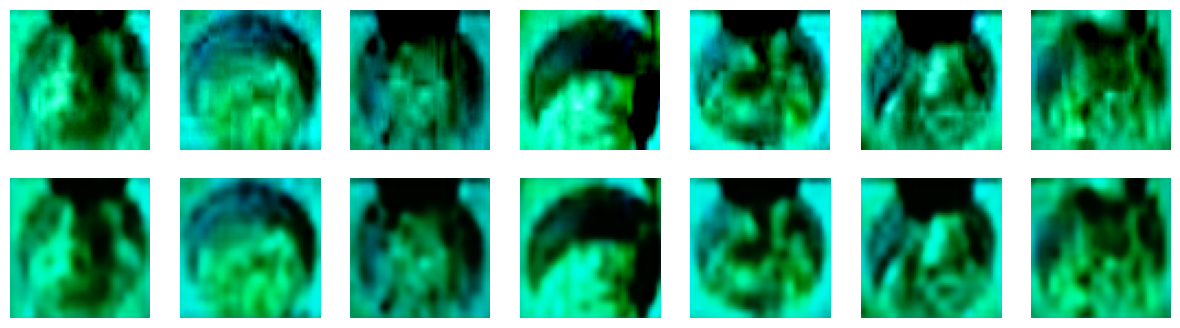

In [30]:
test_dl = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
)

with torch.no_grad():
    for data, _ in test_dl:
        data = data.to(device)
        recon = model(data)
        break

print(data.shape, recon.shape)
plt.figure(dpi=250)
fig, ax = plt.subplots(2, 7, figsize=(15, 4))
for i in range(7):
    ax[0, i].imshow(data[i].cpu().numpy().transpose((1, 2, 0)))
    ax[1, i].imshow(recon[i].cpu().numpy().transpose((1, 2, 0)))
    ax[0, i].axis('OFF')
    ax[1, i].axis('OFF')

In [31]:
def predict_label(model, image, thresh, criterion, device):
  pred = model(image.to(device))
  #flat = torch.flatten(image.to(device), start_dim=1)
  loss = criterion(image.to(device), pred)

  if loss > thresh: return 1
  else: return 0

In [33]:
test_dl = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

low_thr = 40
high_thr= 150
step = 10
cur_thr = low_thr

best_thr= -1
best_f1 = -1

metrics = defaultdict(list)
TP, TN, FP, FN = 0, 0, 0, 0
model.eval()

while (cur_thr < high_thr):
  for i, (image, label) in enumerate(test_dl):
    pred_label = predict_label(model, image, cur_thr, criterion, device)

    if label == 0:
      if pred_label == 0: TN += 1
      elif pred_label == 1: FP += 1
    elif label == 1:
      if pred_label == 0: FN += 1
      elif pred_label == 1: TP += 1

  precision = TP / (TP + FP)
  recall = TP / (TP + FN)
  f1 = 2 * precision * recall / (precision + recall)

  if f1 > best_f1:
    best_thr = cur_thr
    best_f1 = f1

  metrics['precision'].append(precision)
  metrics['recall'].append(recall)
  metrics['f1'].append(f1)

  wandb.log({'threshold': thr,
             'precision': precision,
             'recall': recall,
             'f1': f1})

  print('\n-----------------------------------------------')
  print(f'threshold: {cur_thr:.6f}\tprecision: {precision:.4f}\trecall: {recall:.4f}\tf1 {f1:.4f}')

  cur_thr += step



-----------------------------------------------
threshold: 40.000000	precision: 0.2571	recall: 0.7674	f1 0.3852

-----------------------------------------------
threshold: 50.000000	precision: 0.3345	recall: 0.7636	f1 0.4652

-----------------------------------------------
threshold: 60.000000	precision: 0.4112	recall: 0.7597	f1 0.5336

-----------------------------------------------
threshold: 70.000000	precision: 0.4677	recall: 0.7578	f1 0.5784

-----------------------------------------------
threshold: 80.000000	precision: 0.5159	recall: 0.7550	f1 0.6130

-----------------------------------------------
threshold: 90.000000	precision: 0.5563	recall: 0.7532	f1 0.6400

-----------------------------------------------
threshold: 100.000000	precision: 0.5904	recall: 0.7519	f1 0.6615

-----------------------------------------------
threshold: 110.000000	precision: 0.6190	recall: 0.7510	f1 0.6786

-----------------------------------------------
threshold: 120.000000	precision: 0.6447	recal

In [34]:
# with my selected threshold as 100 I would get f1 0.66 on test-split
